# Неделя 1 — EDA

Задание: `docs/week1_eda.md`

## 1. Загрузка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from src.eda import explore, churn_rate_by, missing_months



In [2]:
# Клиенты
clients = pd.read_excel('../data/raw/clients.xlsx')

# Помесячное потребление - лежит по месяцам, читаем и склеиваем один раз,
# дальше работаем только с parquet (см. docs/data_dictionary.md)
import glob
usage_files = sorted(glob.glob('../data/raw/usage/*.csv'))
usage = pd.concat([pd.read_csv(f) for f in usage_files], ignore_index=True)

clients.to_parquet('../data/processed/clients.parquet')
usage.to_parquet('../data/processed/usage.parquet')
print(clients.shape, usage.shape)

(50400, 8) (1073079, 7)


## 2. Чек-лист EDA

Пройдитесь по 7 вопросам из `docs/week1_eda.md` для каждой таблицы.

In [3]:
explore(clients, 'Клиенты')
explore(usage, 'Использование')

# clients["is_explicit_churn"]
display(clients["product"].value_counts())
display(clients.duplicated().sum())
display(usage.duplicated(["client_id", "month"]).sum())
# usage.boxplot(column="revenue")

numeric_columns = [
    "revenue",
    "traffic_gb",
    "n_tickets",
    "debt",
    "n_sim",
]
display((usage[numeric_columns] == 0).sum())
usage[numeric_columns].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]
).T



===== Клиенты =====
Размер: 50400 строк, 8 столбцов
                  тип  пропусков  пропусков_%  уникальных
client_id         str          0          0.0       50400
segment           str          0          0.0           3
product           str          0          0.0           4
region            str          0          0.0           5
company_name      str          0          0.0       19360
connection_date   str          0          0.0          58
termination_date  str      36361         72.1          27
current_status    str          0          0.0           2
===== Использование =====
Размер: 1073079 строк, 7 столбцов
                тип  пропусков  пропусков_%  уникальных
client_id       str          0          0.0       50400
month           str          0          0.0          30
revenue     float64          0          0.0     1016925
traffic_gb  float64          0          0.0       26650
n_tickets     int64          0          0.0          13
debt        float64          0

product
мобильная связь     12676
интернет            12634
телефония           12627
облачные сервисы    12463
Name: count, dtype: int64

np.int64(0)

np.int64(0)

revenue            0
traffic_gb       835
n_tickets     812097
debt          980666
n_sim          37417
dtype: int64

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
revenue,1073079.0,195748.366004,405595.089793,5.61,440.3,11491.77,36753.69,148590.235,1014490.215,1.934893e+06,10777345.63
traffic_gb,1073079.0,193.764809,407.923828,0.00,0.4,11.20,36.00,147.700,1003.100,1.955044e+03,11640.40
n_tickets,1073079.0,0.333378,0.703288,0.00,0.0,0.00,0.00,0.000,2.000,3.000000e+00,12.00
debt,1073079.0,109.146730,401.861864,0.00,0.0,0.00,0.00,0.000,1102.721,2.055941e+03,4477.13
n_sim,1073079.0,34.796549,68.696579,0.00,0.0,2.00,5.00,20.000,221.000,2.840000e+02,351.00


## 3. Доля оттока по сегментам/продуктам/регионам

In [9]:
clients["is_explicit_churn"]= (
    clients["termination_date"].notna().astype(int)
)
display(churn_rate_by(clients, target_col='is_explicit_churn', group_col='segment'))
display(churn_rate_by(clients, target_col='is_explicit_churn', group_col='region'))
display(churn_rate_by(clients, target_col='is_explicit_churn', group_col='product'))

# display(clients.groupby("segment")["is_explicit_churn"].mean() * 100)
# display(clients.groupby("region")["is_explicit_churn"].mean() * 100)
# clients.groupby("product")["is_explicit_churn"].mean() * 100
# clients["is_explicit_churn"].mean()

month_stats = missing_months(usage)
print("Клиентов с дырами:", month_stats["has_gap"].sum())

print(month_stats["n_months_actual"].agg(["min", "median", "max"]))

print("Полная история:", (month_stats["n_months_actual"] == 30).sum())

,доля_оттока,клиентов
segment,,
малый бизнес,0.308758,24388
средний бизнес,0.275953,17079
крупный бизнес,0.201052,8933


,доля_оттока,клиентов
region,,
Юг,0.285502,10105
Москва,0.281824,9914
Урал,0.276446,10096
Санкт-Петербург,0.275450,10118
Сибирь,0.273630,10167


,доля_оттока,клиентов
product,,
мобильная связь,0.279978,12676
облачные сервисы,0.279628,12463
телефония,0.279243,12627
интернет,0.275368,12634


Клиентов с дырами: 0
min        3.0
median    24.0
max       30.0
Name: n_months_actual, dtype: float64
Полная история: 19985


## 4. Динамика ушедших vs оставшихся клиентов

Выровнял ушедших не по календарю, а по числу месяцев до расторжения, поделил выручку каждого на его же норму примерно за год до ухода, взял медиану. Получилось 0,90 → 0,69 → 0,37 → 0,13, и тикеты в это же время растут с 0,27 до 1,86. У 65 процентов в последний месяц меньше десятой части от нормы. Из десяти картинок получилась одна, зато с цифрой.

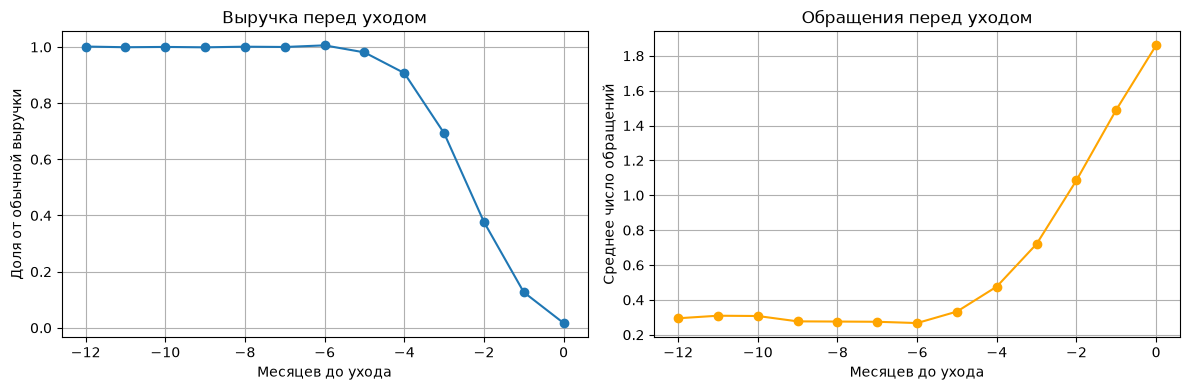

In [34]:
terminated = clients.dropna(
    subset=["termination_date"]
)[["client_id", "termination_date"]]

before_churn = usage.merge(
    terminated,
    on="client_id",
    how="inner",
)
before_churn["k"] = (
    pd.PeriodIndex(before_churn["month"], freq="M").astype("int64")
    - pd.PeriodIndex(
        before_churn["termination_date"],
        freq="M",
    ).astype("int64")
)
before_churn = before_churn[
    before_churn["k"].between(-12, 0)
]

normal_revenue = (
    before_churn[before_churn["k"].between(-12, -7)]
    .groupby("client_id")["revenue"]
    .mean()
)

before_churn["revenue_norm"] = (
    before_churn["revenue"]
    / before_churn["client_id"].map(normal_revenue)
)

churn_dynamics = before_churn.groupby("k").agg(
    revenue_median=("revenue_norm", "median"),
    tickets_mean=("n_tickets", "mean")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_dynamics["revenue_median"].plot(
    ax=axes[0], marker="o"
)
axes[0].set_title("Выручка перед уходом")
axes[0].set_xlabel("Месяцев до ухода")
axes[0].set_ylabel("Доля от обычной выручки")
axes[0].grid()

churn_dynamics["tickets_mean"].plot(
    ax=axes[1], marker="o", color="orange"
)
axes[1].set_title("Обращения перед уходом")
axes[1].set_xlabel("Месяцев до ухода")
axes[1].set_ylabel("Среднее число обращений")
axes[1].grid()

plt.tight_layout()
plt.show()

In [15]:
active_client_ids = clients.loc[
    clients["current_status"] == "Активен",
    "client_id"    
]

active_usage = usage[
    usage["client_id"].isin(active_client_ids)
]

normal_level = (
    active_usage[
        active_usage["month"].between("2025-10", "2025-12")
        ].groupby("client_id")[["revenue", "n_sim"]]
        .mean()
)

last_level = (
    active_usage[
        active_usage["month"].between("2026-04", "2026-06")
        ].groupby("client_id")[["revenue", "n_sim"]]
        .mean()
)

silent_churn_data = normal_level.join(
    last_level,
    how="inner",
    lsuffix="_normal",
    rsuffix="_last",
)
display(silent_churn_data.head())
display(silent_churn_data.shape)

silent_churn_data["revenue_ratio"] = (
    silent_churn_data["revenue_last"]
    / (silent_churn_data["revenue_normal"] + 1e-9)
)

silent_churn_data["sim_ratio"] = (
    silent_churn_data["n_sim_last"]
    / (silent_churn_data["n_sim_normal"] + 1e-9)
)

silent_churn_clients = silent_churn_data[
    (silent_churn_data["revenue_ratio"] < 0.3)
    & (silent_churn_data["sim_ratio"] < 0.3)
]

len(silent_churn_data)

,revenue_normal,n_sim_normal,revenue_last,n_sim_last
client_id,,,,
CL000001,1.400484e+06,67.333333,1.247992e+06,69.000000
CL000004,1.086792e+05,14.666667,1.184834e+05,15.333333
CL000008,5.803338e+05,53.000000,6.547031e+05,52.333333
CL000013,9.437724e+04,21.666667,8.520590e+04,23.000000
CL000015,1.529361e+05,12.000000,1.557851e+05,12.666667


(34967, 4)

connection_date
2025-07    912
2025-08    902
2025-09    900
2025-10    872
2025-11    912
2025-12    926
2026-01    934
2026-02    930
2026-03     28
2026-04     27
Name: count, dtype: int64


termination_date
2024-04    224
2024-05    247
2024-06    248
2024-07    256
2024-08    290
2024-09    328
2024-10    314
2024-11    328
2024-12    358
2025-01    394
Name: count, dtype: int64

## Распределение по подключениям/расторжениям

In [ ]:


connection_counts = (
    clients["connection_date"]
    .value_counts()
    .sort_index()
)

print(connection_counts.tail(10))

termination_counts = (
    clients["termination_date"]
    .value_counts()
    .sort_index()
)

termination_counts.head(10)

### Находки   
в марте резко возрасло количество обращений в поддержку и упал трафик


In [18]:
monthly_stats = usage.groupby("month").agg(
    tickets_mean=("n_tickets", "mean"),
    traffic_median=("traffic_gb", "median"),
)
monthly_stats.loc[
    ["2025-02", "2025-03", "2025-04"]
]

,tickets_mean,traffic_median
month,,
2025-02,0.271764,38.8
2025-03,1.778568,26.9
2025-04,0.286725,37.7


### Выбросы

In [22]:
zero_sim_with_revenue = usage[
    (usage["n_sim"] == 0)
    & (usage["revenue"] > 1000)
]
# len(zero_sim_with_revenue)      = 21906
# zero_sim_with_revenue.head(10)

zero_sim_with_revenue.merge(
    clients[["client_id", "product"]],
    on="client_id",
    how="left",
)["product"].value_counts()

product
интернет            5613
телефония           5575
мобильная связь     5487
облачные сервисы    5231
Name: count, dtype: int64

#### Проверка ключа

Название компании не является ключом, так как 19360 компаний приходится на 50400 клиентов и записи могут повторятсья. 

Таблицы связываются по client_id

In [24]:
print(clients["client_id"].nunique())
clients["company_name"].nunique()

50400


19360

## 5. Выводы

TODO: сформулируйте 3-5 наблюдений об аномалиях, объёме данных и первой проверке гипотезы про сегменты.

Всего клиентов 50400, записей о использование 1073079 за 30 месяцев

Дубликатов, пропусков в usage не найдено. 

Верхний 1% значений выручки относится не к одному клиенту, а к 798 клиентам крупного бизнеса.

По поводу гипотезы про оттоки по сегментам. Самый большой отток (30% против 27 и 20%) наблюдается среди малого бизнеса, оно и логично.

Малые бизнесы чаще меняют оператора и закрываются.    
